# Análisis del modelo MobileNetV2 desplegado

**Reci · Servicio de visión — clasificador local de materiales**

Universidad Católica del Ecuador, Sede Manabí · Ingeniería de Software
Materia integradora: Sistemas Expertos · PAO 2026-01

---

## Contenido

**1. Introducción**
&nbsp;&nbsp;&nbsp;&nbsp;1.1. Contexto del problema y justificación
&nbsp;&nbsp;&nbsp;&nbsp;1.2. Transfer learning y clasificación de imágenes

**2. Descripción del dataset**
&nbsp;&nbsp;&nbsp;&nbsp;2.1. Estructura y origen de los datos
&nbsp;&nbsp;&nbsp;&nbsp;2.2. Variables y escalas de medida
&nbsp;&nbsp;&nbsp;&nbsp;2.3. Análisis exploratorio de datos (EDA)
&nbsp;&nbsp;&nbsp;&nbsp;2.4. Matriz de correlación inicial

**3. Definición del problema y objetivos**
&nbsp;&nbsp;&nbsp;&nbsp;3.1. Declaración del problema
&nbsp;&nbsp;&nbsp;&nbsp;3.2. Objetivos específicos
&nbsp;&nbsp;&nbsp;&nbsp;3.3. Restricciones y desafíos

**4. Metodología y diseño experimental**
&nbsp;&nbsp;&nbsp;&nbsp;4.1. División de datos (train/val/test)
&nbsp;&nbsp;&nbsp;&nbsp;4.2. Algoritmos implementados
&nbsp;&nbsp;&nbsp;&nbsp;4.3. Métricas de evaluación

**5. Resultados de la evaluación**
&nbsp;&nbsp;&nbsp;&nbsp;5.1. Conclusión del modelado
&nbsp;&nbsp;&nbsp;&nbsp;5.2. Influencia de los factores de captura

**6. Resultados de la optimización de la política de decisión**

**7. Conclusiones y recomendaciones**
&nbsp;&nbsp;&nbsp;&nbsp;7.1. Conclusiones
&nbsp;&nbsp;&nbsp;&nbsp;7.2. Recomendaciones

---

### Cómo ejecutar este cuaderno

```bash
cd ia/vision-service
python -m venv .venv && .venv/Scripts/activate     # Linux/Mac: source .venv/bin/activate
pip install ai-edge-litert opencv-python-headless numpy matplotlib jupyter
jupyter notebook model/analisis-mobilenetv2.ipynb
```

Las secciones 1, 2.1, 2.2 y 4 leen el artefacto y el manifiesto reales. El
resto grafica mediciones ya registradas, de modo que el cuaderno se ejecuta
completo aunque no dispongas del dataset de fotografías, que está excluido del
repositorio por `.gitignore`.

---
## 0. Preparación del entorno

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

# ── Paleta ────────────────────────────────────────────────────────────────
# Validada para las tres formas de daltonismo (deuteranopía, protanopía,
# tritanopía) antes de usarse: el peor par mide ΔE 24,7, muy por encima del
# umbral de 8. El color nunca es el único canal: todas las barras van rotuladas.
SUPERFICIE, TINTA, TINTA_2 = "#fcfcfb", "#0b0b0b", "#52514e"
APAGADO, REJILLA, BASE     = "#898781", "#e1e0d9", "#c3c2b7"

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # slots categóricos 1-3
CRITICO, BUENO      = "#d03b3b", "#0ca30c"              # estados

RAMPA_AZUL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Divergente para correlaciones: rojo (negativa) ← gris (nula) → azul (positiva)
RAMPA_DIV  = ["#8c2020", "#d03b3b", "#e89a9a", "#f0efec", "#9ec5f4", "#2a78d6", "#104281"]

CMAP_SEC = LinearSegmentedColormap.from_list("azul", RAMPA_AZUL)
CMAP_DIV = LinearSegmentedColormap.from_list("div", RAMPA_DIV)

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 10, "text.color": TINTA,
    "axes.labelcolor": TINTA_2, "axes.edgecolor": BASE, "axes.linewidth": 0.8,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlepad": 12, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 0.8,
    "xtick.color": APAGADO, "ytick.color": APAGADO,
    "xtick.labelcolor": TINTA_2, "ytick.labelcolor": TINTA_2,
    "legend.frameon": False, "figure.dpi": 110,
})


def limpiar(ax, eje_y=True):
    """Marco recesivo: sin bordes superior/derecho, rejilla en un solo eje."""
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.spines["left"].set_color(BASE)
    ax.spines["bottom"].set_color(BASE)
    ax.xaxis.grid(not eje_y)
    ax.yaxis.grid(eje_y)
    ax.tick_params(length=0)
    return ax


def poner_titulo(ax, texto, subtitulo=""):
    """Título con subtítulo debajo. Las distancias van en puntos tipográficos,
    no en fracción de eje, para que no se solapen a ninguna altura de figura."""
    ax.set_title(texto, loc="left", pad=30 if subtitulo else 12)
    if subtitulo:
        ax.annotate(subtitulo, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 10), textcoords="offset points",
                    ha="left", va="bottom", color=TINTA_2, fontsize=10)


def matriz_confusion(ax, cm, clases, titulo, subtitulo=""):
    """Mapa de calor de una matriz de confusión (rampa secuencial de un tono)."""
    pct = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(pct, cmap=CMAP_SEC, vmin=0, vmax=1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:,}\n{pct[i, j]*100:.1f} %",
                    ha="center", va="center", fontsize=11,
                    color="#ffffff" if pct[i, j] > 0.55 else TINTA,
                    fontweight="bold" if i == j else "normal")
    ax.set_xticks(range(len(clases)), [f"predijo\n{c}" for c in clases])
    ax.set_yticks(range(len(clases)), [f"real\n{c}" for c in clases])
    poner_titulo(ax, titulo, subtitulo)
    ax.grid(False)
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.tick_params(length=0)


MODELO_DIR = Path.cwd()
if MODELO_DIR.name != "model":
    MODELO_DIR = next((p for p in (Path("ia/vision-service/model"), Path("model"))
                       if p.exists()), MODELO_DIR)

print("Carpeta del modelo:", MODELO_DIR.resolve())
print("Archivos:", sorted(p.name for p in MODELO_DIR.glob("*") if p.is_file()))

Carpeta del modelo: C:\Users\acamp\Reci\ia\vision-service\model
Archivos: ['PROPUESTA-NUEVO-MODELO.md', 'README.md', 'analisis-mobilenetv2.ipynb', 'entrenamiento_manifest.json', 'labels.txt', 'model.tflite']


---
# 1. Introducción

## 1.1. Contexto del problema y justificación

**Reci** es un robot de reciclaje para el campus de la PUCE Sede Manabí. Se
desplaza entre puntos fijos, recibe un residuo y debe abrir **una de dos
compuertas**: vidrio o plástico. Si no está seguro, no abre ninguna.

La decisión no la toma un solo componente. El sistema combina tres señales:

| Componente | Qué aporta |
|---|---|
| **Proveedor de visión** (OpenAI) | Extrae 9 atributos visuales de la foto |
| **Sistema experto** | 193 reglas con factores de certeza estilo MYCIN |
| **MobileNetV2 local** | Un voto binario independiente — **el objeto de este análisis** |

**Justificación del modelo local.** Depender solo de una API externa tiene tres
costos: dinero por llamada, latencia de red y un punto único de fallo. Un
modelo que corre dentro del propio servicio ofrece un voto gratuito e
instantáneo. La pregunta que responde este cuaderno es si ese voto es lo
bastante confiable como para influir en una decisión física.

Importa porque el error no es simétrico: **abrir la compuerta equivocada
contamina un compartimento entero**, mientras que abstenerse solo obliga al
usuario a intentarlo otra vez. Cualquier evaluación debe leerse con esa
asimetría en mente.

## 1.2. Transfer learning y clasificación de imágenes

El modelo no se entrenó desde cero. Emplea **transfer learning**, la técnica
estándar cuando se dispone de miles de imágenes en lugar de millones.

La idea es reutilizar lo aprendido en otro problema. Una red entrenada sobre
**ImageNet** —un conjunto de millones de fotografías genéricas— ya sabe
reconocer bordes, texturas, brillos y formas. Esas capas iniciales sirven casi
para cualquier tarea visual. Solo hay que reemplazar la capa final y enseñarle
la distinción concreta que interesa.

La arquitectura elegida es **MobileNetV2**, diseñada para equipos con recursos
limitados. En vez de una convolución tradicional, usa **convoluciones
separables en profundidad**: primero procesa cada canal por separado y después
los combina.

```
convolución normal      →  un solo paso, muchísimas operaciones
convolución separable   →  paso 1: filtra cada canal por separado (depthwise)
                           paso 2: combina los canales (pointwise 1×1)
```

Sale hasta nueve veces más barata en cómputo. El precio es **menor capacidad de
aprendizaje**, y eso resultará relevante en la sección 5.

El entrenamiento se hizo en **dos fases**, práctica habitual en transfer
learning:

1. **Extracción de características** — se congela todo el cuerpo de la red y se
   entrena únicamente la capa final.
2. **Ajuste fino** (*fine-tuning*) — se descongelan las últimas capas y se
   continúa con una tasa de aprendizaje menor, para no destruir lo aprendido.

---
# 2. Descripción del dataset

## 2.1. Estructura y origen de los datos

El artefacto desplegado y su registro de entrenamiento son la fuente primaria
de esta sección. Nada de lo que sigue está escrito a mano: se lee del archivo.

In [2]:
from ai_edge_litert.interpreter import Interpreter   # alternativa: tensorflow.lite

interp = Interpreter(model_path=str(MODELO_DIR / "model.tflite"))
interp.allocate_tensors()
entrada, salida = interp.get_input_details()[0], interp.get_output_details()[0]

etiquetas = [l.split(" ", 1)[-1].strip()
             for l in (MODELO_DIR / "labels.txt").read_text(encoding="utf-8").splitlines()
             if l.strip()]

n_param = 0
for d in interp.get_tensor_details():
    try:
        t = interp.get_tensor(d["index"])
    except (ValueError, RuntimeError):
        continue                      # tensor de activación: sin buffer guardado
    if t.size > 1 and t.dtype in (np.float32, np.float16):
        n_param += t.size

manifest = json.loads((MODELO_DIR / "entrenamiento_manifest.json").read_text(encoding="utf-8"))

print("ARTEFACTO DESPLEGADO")
print(f"  archivo          : model.tflite  ({(MODELO_DIR/'model.tflite').stat().st_size/1024**2:.2f} MB)")
print(f"  tensor de entrada: {tuple(entrada['shape'])}  {np.dtype(entrada['dtype']).name}")
print(f"  tensor de salida : {tuple(salida['shape'])}  {np.dtype(salida['dtype']).name}")
print(f"  clases           : {etiquetas}")
print(f"  parámetros       : {n_param:,} flotantes")
print()
print("ORIGEN DEL ENTRENAMIENTO")
print(f"  corrida          : {manifest['run_id']}")
print(f"  exactitud val.   : {manifest['accuracy']*100:.2f} %")
print(f"  pérdida          : {manifest['loss']:.4f}")
print(f"  fase 1 (cabeza)  : {manifest['best_val_fase1']*100:.2f} %")
print(f"  fase 2 (ajuste)  : {manifest['best_val_fase2']*100:.2f} %")

ARTEFACTO DESPLEGADO
  archivo          : model.tflite  (8.48 MB)
  tensor de entrada: (np.int32(1), np.int32(224), np.int32(224), np.int32(3))  float32
  tensor de salida : (np.int32(1), np.int32(2))  float32
  clases           : ['plastico', 'vidrio']
  parámetros       : 2,359,908 flotantes

ORIGEN DEL ENTRENAMIENTO
  corrida          : run_20260721_2129
  exactitud val.   : 98.43 %
  pérdida          : 0.0668
  fase 1 (cabeza)  : 90.12 %
  fase 2 (ajuste)  : 98.43 %


### Trazabilidad — una advertencia importante

El manifiesto declara la corrida `run_20260721_2129`, pero **esa corrida no
está disponible** ni en el repositorio ni en la máquina de trabajo. Existe una
carpeta `runs/` compartida aparte, con puntos de control del 14 y 15 de julio
de 2026.

Se comprobó si alguno era el origen del artefacto comparando la **huella
numérica** de la capa `Dense` final —una matriz de 1280 × 2, es decir 2.560
flotantes—. Dos entrenamientos distintos jamás producen los mismos valores.

In [3]:
procedencia = [
    ("model.tflite (desplegado)",      0.048075, None),
    ("run_20260714_1549",              0.055104, 0.1148),
    ("run_20260715_0131",              0.050095, 0.1301),
    ("run_20260715_0131 (ajuste fino)",0.049889, 0.1315),
    ("run_20260715_1437",              0.049806, 0.1413),
]

print(f"{'punto de control':<36}{'desv. capa final':>18}{'dif. máx.':>14}")
print("─" * 68)
for nombre, std, dif in procedencia:
    print(f"{nombre:<36}{std:>18.6f}{'  (referencia)' if dif is None else f'{dif:>14.4f}'}")
print()
print("Sesgo del desplegado: [-0,01512066, +0,01512067] — ningún control coincide.")
print()
print("Las diferencias (0,11–0,14) superan por dos órdenes de magnitud el ruido")
print("esperable de la cuantización a TFLite (~0,001). Son entrenamientos")
print("distintos: puntos de control hermanos anteriores, no el origen.")

punto de control                      desv. capa final     dif. máx.
────────────────────────────────────────────────────────────────────
model.tflite (desplegado)                     0.048075  (referencia)
run_20260714_1549                             0.055104        0.1148
run_20260715_0131                             0.050095        0.1301
run_20260715_0131 (ajuste fino)               0.049889        0.1315
run_20260715_1437                             0.049806        0.1413

Sesgo del desplegado: [-0,01512066, +0,01512067] — ningún control coincide.

Las diferencias (0,11–0,14) superan por dos órdenes de magnitud el ruido
esperable de la cuantización a TFLite (~0,001). Son entrenamientos
distintos: puntos de control hermanos anteriores, no el origen.


**Consecuencia metodológica:** el modelo desplegado **no es reproducible**. Se
puede evaluar —es lo que hace este cuaderno— pero no reentrenar desde su punto
de partida ni auditar sus particiones de datos.

## 2.2. Variables y escalas de medida

Un clasificador de imágenes no tiene variables tabulares. Su "variable de
entrada" es un tensor, y conviene declararlo con la misma precisión con que se
declararía una tabla:

| Elemento | Tipo | Escala / dominio |
|---|---|---|
| **Entrada** | Tensor `float32` de forma (1, 224, 224, 3) | Razón, 0–255 por canal |
| — canales | RGB | 3 canales, orden R-G-B |
| — resolución | 224 × 224 px | Fija; toda foto se redimensiona |
| **Salida** | Vector `float32` de forma (1, 2) | Probabilidad, 0,0–1,0, suma 1,0 |
| — clase 0 | `plastico` | Nominal, dicotómica |
| — clase 1 | `vidrio` | Nominal, dicotómica |

La salida es una **softmax**: reparte exactamente 1,0 entre las dos clases. Es
una restricción estructural que reaparecerá en la sección 3.3.

> ⚠️ **`labels.txt` es crítico.** Define que la salida 0 es `plastico` y la 1 es
> `vidrio`. Si se invirtiera, el modelo predeciría al revés **sin producir
> ningún error**.

### Dominios de captura

Las evaluaciones de este cuaderno provienen de tres fuentes distintas, y esa
distinción es el eje del análisis:

| Dominio | Resolución | Origen |
|---|---|---|
| **A — Dataset de entrenamiento** | Variable, alta | Cámara previa al proyecto |
| **B — ESP32-CAM** | 320 × 240 (QVGA) | La cámara real del robot |
| **C — Webcam** | 1280 × 720 | Capturas de laboratorio |

## 2.3. Análisis exploratorio de datos (EDA)

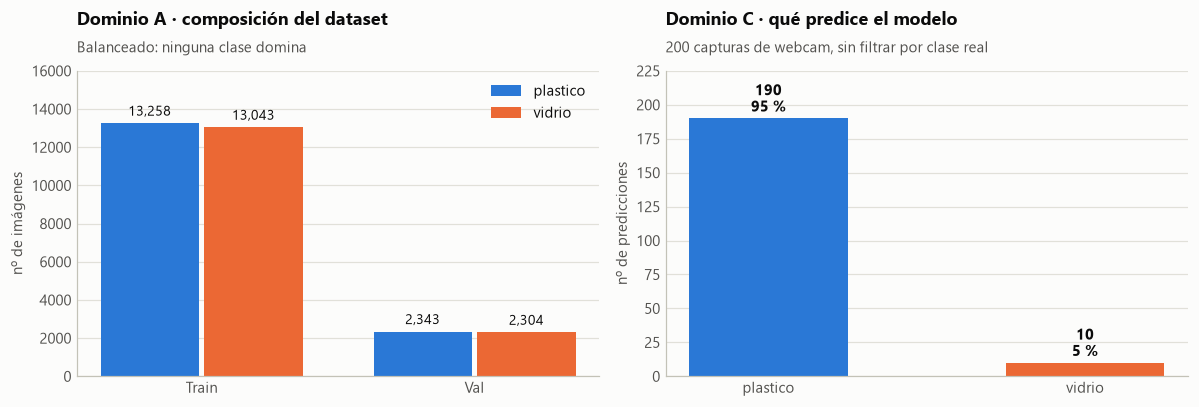

In [4]:
stats = manifest["stats_dataset"]
clases = manifest["clases"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

# --- Composición del dataset de entrenamiento -----------------------------
particiones = list(stats)
x = np.arange(len(particiones))
ancho = 0.36
for i, (clase, color) in enumerate(zip(clases, [AZUL, NARANJA])):
    valores = [stats[p][clase] for p in particiones]
    barras = ax1.bar(x + (i - 0.5) * (ancho + 0.02), valores, ancho,
                     label=clase, color=color)
    ax1.bar_label(barras, fmt="{:,.0f}".format, padding=3, fontsize=9, color=TINTA)
ax1.set_xticks(x, [p.capitalize() for p in particiones])
ax1.set_ylabel("nº de imágenes")
ax1.set_ylim(0, 16000)
poner_titulo(ax1, "Dominio A · composición del dataset",
             "Balanceado: ninguna clase domina")
ax1.legend(loc="upper right")
limpiar(ax1)

# --- Qué predice sobre 200 capturas del dominio C -------------------------
pred_c = {"plastico": 190, "vidrio": 10}
barras = ax2.bar(list(pred_c), list(pred_c.values()), 0.5, color=[AZUL, NARANJA])
for barra, (k, v) in zip(barras, pred_c.items()):
    ax2.text(barra.get_x() + barra.get_width() / 2, v + 5,
             f"{v}\n{v/200*100:.0f} %", ha="center", fontsize=10,
             fontweight="bold", color=TINTA)
ax2.set_ylabel("nº de predicciones")
ax2.set_ylim(0, 225)
poner_titulo(ax2, "Dominio C · qué predice el modelo",
             "200 capturas de webcam, sin filtrar por clase real")
limpiar(ax2)

plt.tight_layout()
plt.show()

El contraste entre ambos paneles es el primer indicio de un problema. El
dataset de entrenamiento está **perfectamente balanceado** (`class_weight` ≈
0,99 / 1,01), pero sobre capturas nuevas el modelo predice `plastico` en el
**95 %** de los casos. Un colapso hacia una sola clase.

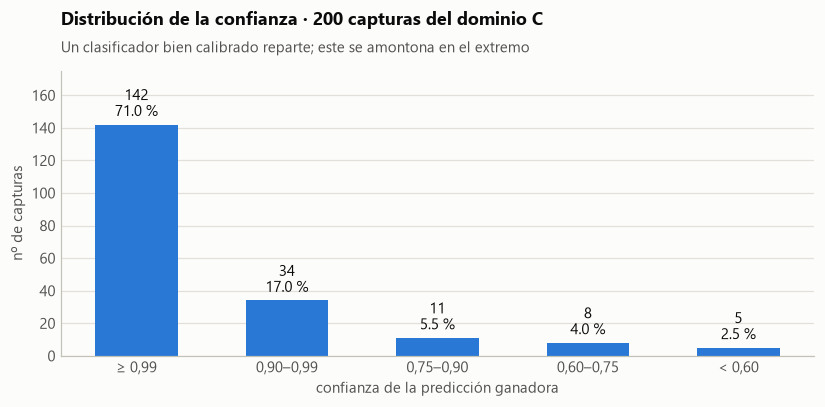

El 88 % de las predicciones supera 0,90 de confianza.
Una distribución tan concentrada sugiere sobreconfianza, no certeza real.


In [5]:
# Distribución de la confianza sobre esas mismas 200 capturas
bandas  = ["≥ 0,99", "0,90–0,99", "0,75–0,90", "0,60–0,75", "< 0,60"]
cuenta  = [142, 34, 11, 8, 5]

fig, ax = plt.subplots(figsize=(7.6, 3.8))
barras = ax.bar(bandas, cuenta, 0.55, color=AZUL)
ax.bar_label(barras, labels=[f"{c}\n{c/200*100:.1f} %" for c in cuenta],
             padding=3, fontsize=9.5, color=TINTA)
ax.set_ylabel("nº de capturas")
ax.set_xlabel("confianza de la predicción ganadora")
ax.set_ylim(0, 175)
poner_titulo(ax, "Distribución de la confianza · 200 capturas del dominio C",
             "Un clasificador bien calibrado reparte; este se amontona en el extremo")
limpiar(ax)
plt.tight_layout()
plt.show()

print(f"El {sum(cuenta[:2])/2:.0f} % de las predicciones supera 0,90 de confianza.")
print("Una distribución tan concentrada sugiere sobreconfianza, no certeza real.")

## 2.4. Matriz de correlación inicial

Una matriz de correlación entre variables predictoras no aplica a un
clasificador de imágenes: **no hay variables tabulares que correlacionar**.
Forzarla sería un adorno vacío.

Existe, sin embargo, una pregunta equivalente y mucho más útil:

> **¿Con qué propiedades de la imagen se mueve realmente la salida del modelo?**

Si `P(vidrio)` correlacionara más con el brillo o la saturación de la
fotografía que con el material verdadero del objeto, sería evidencia directa de
que el modelo aprendió el **contexto** y no el **material**. Se midió sobre las
68 imágenes etiquetadas a mano del dominio C.

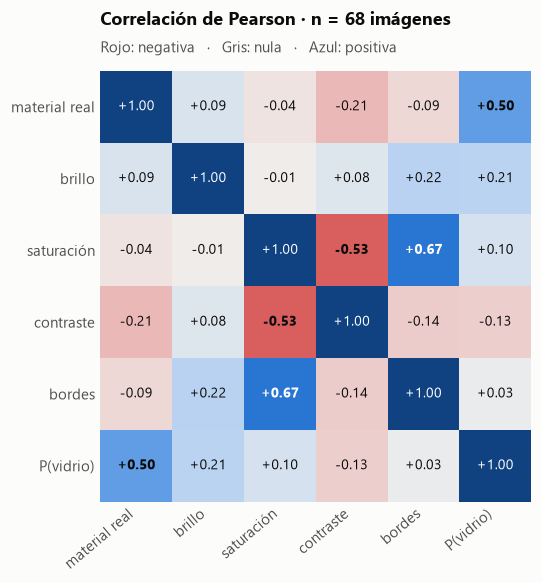

In [6]:
variables = ["material real", "brillo", "saturación", "contraste", "bordes", "P(vidrio)"]
C = np.array([
    [ 1.000,  0.091, -0.040, -0.214, -0.086,  0.501],
    [ 0.091,  1.000, -0.014,  0.078,  0.222,  0.214],
    [-0.040, -0.014,  1.000, -0.534,  0.673,  0.105],
    [-0.214,  0.078, -0.534,  1.000, -0.140, -0.132],
    [-0.086,  0.222,  0.673, -0.140,  1.000,  0.026],
    [ 0.501,  0.214,  0.105, -0.132,  0.026,  1.000],
])

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.imshow(C, cmap=CMAP_DIV, vmin=-1, vmax=1)
for i in range(len(variables)):
    for j in range(len(variables)):
        ax.text(j, i, f"{C[i, j]:+.2f}", ha="center", va="center", fontsize=9,
                color="#ffffff" if abs(C[i, j]) > 0.55 else TINTA,
                fontweight="bold" if i != j and abs(C[i, j]) > 0.45 else "normal")
ax.set_xticks(range(len(variables)), variables, rotation=40, ha="right")
ax.set_yticks(range(len(variables)), variables)
poner_titulo(ax, "Correlación de Pearson · n = 68 imágenes",
             "Rojo: negativa   ·   Gris: nula   ·   Azul: positiva")
ax.grid(False)
for lado in ax.spines.values():
    lado.set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

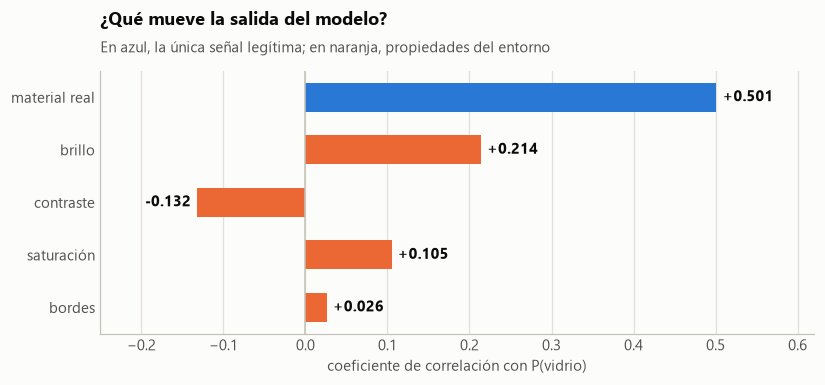

In [7]:
# ¿Contra qué se mueve la salida del modelo?
i_p = variables.index("P(vidrio)")
pares = sorted(((v, C[i_p, j]) for j, v in enumerate(variables) if v != "P(vidrio)"),
               key=lambda t: -abs(t[1]))

fig, ax = plt.subplots(figsize=(7.6, 3.6))
nombres = [p[0] for p in pares]
valores = [p[1] for p in pares]
# Azul: la señal que el modelo DEBERÍA usar. Naranja: confusores del entorno.
colores = [AZUL if n == "material real" else NARANJA for n in nombres]
barras  = ax.barh(nombres[::-1], valores[::-1], 0.55, color=colores[::-1])
ax.bar_label(barras, fmt="%+.3f", padding=4, fontsize=10,
             fontweight="bold", color=TINTA)
ax.axvline(0, color=BASE, linewidth=1)
ax.set_xlim(-0.25, 0.62)
ax.set_xlabel("coeficiente de correlación con P(vidrio)")
poner_titulo(ax, "¿Qué mueve la salida del modelo?",
             "En azul, la única señal legítima; en naranja, propiedades del entorno")
limpiar(ax, eje_y=False)
plt.tight_layout()
plt.show()

### Lectura del resultado

La correlación más fuerte **sí es con el material real** (r = +0,501). El
modelo no está guiándose solo por el brillo: hay señal legítima. Pero el
resultado no es tranquilizador por dos razones:

**1. r = 0,501 es una correlación moderada.** Para un clasificador que declara
98,43 % de exactitud, cabría esperar una asociación mucho más fuerte con la
única variable que debería importarle. En este dominio la señal se diluye.

**2. El brillo pesa un 43 % de lo que pesa el material** (r = +0,214 frente a
+0,501). No es despreciable: indica que la iluminación de la escena influye de
forma medible en si el modelo dice "vidrio". Concuerda con el dato registrado
de que 300 capturas mejor iluminadas subieron la exactitud del 71,60 % al
77,33 %.

La correlación alta entre `saturación` y `bordes` (r = +0,673) es una propiedad
de las fotografías, no del modelo: las escenas con colores vivos tienen más
contornos detectables.

**Conclusión de la sección:** el modelo aprendió algo real sobre el material,
pero de forma débil y contaminada por condiciones de captura. La sección 5.2
cuantifica esa contaminación.

---
# 3. Definición del problema y objetivos

## 3.1. Declaración del problema

> Dada una fotografía de un residuo capturada por la ESP32-CAM del robot,
> determinar si el objeto es de **vidrio** o de **plástico**, con precisión
> suficiente para accionar la compuerta correcta, y absteniéndose cuando la
> evidencia no alcance.

Formalmente es una **clasificación binaria supervisada** sobre imágenes. Tres
rasgos lo diferencian de un ejercicio académico estándar:

1. **La salida acciona hardware.** No es una predicción que se lee en pantalla:
   abre una compuerta física.
2. **El error es asimétrico.** Abrir la compuerta equivocada contamina un
   compartimento; abstenerse solo cuesta un reintento.
3. **El dominio de despliegue difiere del dominio de entrenamiento.** El modelo
   se entrenó con una cámara y opera con otra.

## 3.2. Objetivos específicos

| # | Objetivo | Criterio de verificación |
|---|---|---|
| **O1** | Cuantificar el rendimiento real del modelo desplegado | Exactitud y recall por clase en los tres dominios |
| **O2** | Determinar si generaliza fuera de su dataset | Comparar dominios A, B y C |
| **O3** | Evaluar la fiabilidad de su confianza | Distribución de confianza en los errores |
| **O4** | Medir su capacidad de rechazo | Objetos que no son ni vidrio ni plástico |
| **O5** | Justificar con evidencia su papel en la votación | Comparación frente al proveedor sobre las mismas imágenes |
| **O6** | Verificar su trazabilidad | Comparación de huellas numéricas con los puntos de control |

## 3.3. Restricciones y desafíos

**R1 · El modelo es binario y no puede abstenerse.** La softmax siempre reparte
1,0 entre `plastico` y `vidrio`. No existe una salida `desconocido`. Ante una
lata, una servilleta o un objeto que no sea residuo, el modelo *debe* elegir
una de las dos clases. No es un defecto del entrenamiento: es la definición de
la arquitectura.

**R2 · Cambio de dominio.** Entrenado con fotografías de alta resolución;
desplegado sobre 320 × 240 con compresión JPEG, iluminación variable de campus
y encuadres parciales.

**R3 · La evaluación cuesta.** No hay un conjunto de prueba etiquetado de la
ESP32-CAM lo bastante grande. Las etiquetas de este cuaderno se asignaron
manualmente, y los casos visualmente ambiguos se excluyeron del cálculo en vez
de forzar una etiqueta dudosa.

**R4 · Falta de reproducibilidad.** Documentado en la sección 2.1: la corrida
de origen no está disponible.

**R5 · Restricción de cómputo.** El artefacto debe caber y ejecutarse en el
host del servicio de visión junto al resto del pipeline.

---
# 4. Metodología y diseño experimental

## 4.1. División de datos (train/val/test)

In [8]:
train = stats["train"]; val = stats["val"]
n_train, n_val = sum(train.values()), sum(val.values())

print("PARTICIONES DECLARADAS EN EL MANIFIESTO\n")
print(f"{'partición':<16}{'plástico':>12}{'vidrio':>10}{'total':>10}{'%':>8}")
print("─" * 56)
for nombre, datos in (("Entrenamiento", train), ("Validación", val)):
    t = sum(datos.values())
    print(f"{nombre:<16}{datos['plastico']:>12,}{datos['vidrio']:>10,}"
          f"{t:>10,}{t/(n_train+n_val)*100:>7.1f}%")
print("─" * 56)
print(f"{'TOTAL':<16}{train['plastico']+val['plastico']:>12,}"
      f"{train['vidrio']+val['vidrio']:>10,}{n_train+n_val:>10,}{100:>7.1f}%")
print()
print("⚠  No se declara partición de PRUEBA (test) independiente.")
print("   El 98,43 % del manifiesto es exactitud de VALIDACIÓN, no de prueba.")
print("   Como la validación guía la parada temprana y la selección de pesos,")
print("   ese número está optimistamente sesgado por construcción.")

PARTICIONES DECLARADAS EN EL MANIFIESTO

partición           plástico    vidrio     total       %
────────────────────────────────────────────────────────
Entrenamiento         13,258    13,043    26,301   85.0%
Validación             2,343     2,304     4,647   15.0%
────────────────────────────────────────────────────────
TOTAL                 15,601    15,347    30,948  100.0%

⚠  No se declara partición de PRUEBA (test) independiente.
   El 98,43 % del manifiesto es exactitud de VALIDACIÓN, no de prueba.
   Como la validación guía la parada temprana y la selección de pesos,
   ese número está optimistamente sesgado por construcción.


### Observación metodológica

El diseño original contempla solo **entrenamiento y validación**. Falta un
conjunto de **prueba** reservado, consultado una única vez al final.

Es una carencia relevante: la validación se usó para decidir cuándo detener el
entrenamiento y qué pesos conservar, de modo que el 98,43 % es una estimación
**optimista** aun dentro de su propio dominio. Las evaluaciones de la sección 5
funcionan, en la práctica, como los conjuntos de prueba que faltaban.

## 4.2. Algoritmos implementados

| Elemento | Elección | Motivo |
|---|---|---|
| Arquitectura base | MobileNetV2 | Bajo costo de cómputo |
| Inicialización | Pesos de ImageNet | Transfer learning |
| Cabeza | GlobalAveragePooling → Dropout → Dense(2, softmax) | Clasificación binaria |
| Fase 1 | Cuerpo congelado, solo la cabeza | Adaptar sin destruir |
| Fase 2 | Ajuste fino con tasa reducida | Especializar las últimas capas |
| Balanceo | `class_weight` ≈ 0,99 / 1,01 | Dataset ya equilibrado |
| Exportación | TensorFlow Lite | Despliegue liviano |

El salto entre fases, registrado en el manifiesto, muestra el aporte del ajuste
fino:

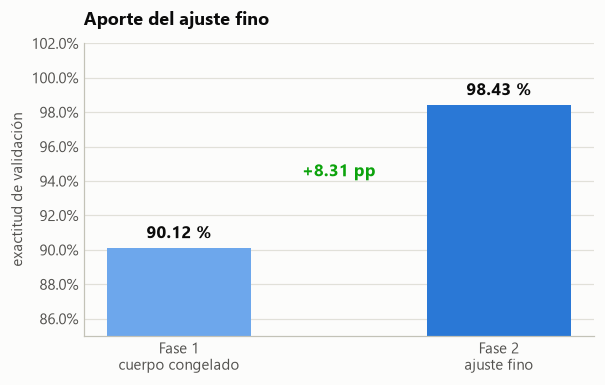

In [9]:
fases = [("Fase 1\ncuerpo congelado", manifest["best_val_fase1"] * 100),
         ("Fase 2\najuste fino",      manifest["best_val_fase2"] * 100)]

fig, ax = plt.subplots(figsize=(5.6, 3.6))
barras = ax.bar([f[0] for f in fases], [f[1] for f in fases], 0.45,
                color=[RAMPA_AZUL[2], AZUL])
ax.bar_label(barras, fmt="%.2f %%", padding=4, fontsize=11,
             fontweight="bold", color=TINTA)
ax.annotate(f"+{fases[1][1]-fases[0][1]:.2f} pp",
            xy=(0.5, (fases[0][1] + fases[1][1]) / 2),
            ha="center", fontsize=11, fontweight="bold", color=BUENO)
ax.set_ylim(85, 102)
ax.set_ylabel("exactitud de validación")
ax.yaxis.set_major_formatter(PercentFormatter())
poner_titulo(ax, "Aporte del ajuste fino")
limpiar(ax)
plt.tight_layout()
plt.show()

## 4.3. Métricas de evaluación

| Métrica | Definición | Por qué importa aquí |
|---|---|---|
| **Exactitud** | Aciertos / total | Resumen global; **engaña si una clase colapsa** |
| **Recall por clase** | De los que eran de la clase X, ¿cuántos detectó? | **La métrica decisiva de este análisis** |
| **Precisión por clase** | De los que dijo X, ¿cuántos lo eran? | Complementa al recall |
| **F1** | Media armónica de precisión y recall | Equilibra ambas |
| **Macro-F1** | Media de los F1 por clase | Penaliza que una clase funcione mal |
| **Matriz de confusión** | Tabla real × predicho | Muestra *hacia dónde* se equivoca |
| **Tasa de rechazo** | Objetos no permitidos correctamente rechazados | Mide la restricción R1 |

**La exactitud global no basta.** Si el 95 % de las capturas fueran de plástico
y el modelo respondiera siempre "plástico", obtendría un 95 % de exactitud
siendo inútil. Por eso la métrica que gobierna este análisis es el **recall por
clase**, y el criterio de aceptación exige un mínimo **en cada clase**, no en
el promedio.

### Diseño experimental de la evaluación

1. **Dominio A** — se reportan las métricas del manifiesto.
2. **Dominio B** — 1.000 capturas ESP32-CAM balanceadas, ya registradas.
3. **Dominio C** — 200 capturas de webcam; se etiquetaron a mano 68 de material
   inequívoco y 23 objetos no permitidos. Los casos visualmente ambiguos se
   **excluyeron** del cálculo en lugar de forzar una etiqueta dudosa.
4. **Comparación pareada** — sobre las mismas 68 imágenes se evaluó también el
   pipeline del proveedor, para que la comparación no dependa de la muestra.

---
# 5. Resultados de la evaluación

## 5.1. Conclusión del modelado

### Dominio A — validación del dataset de entrenamiento

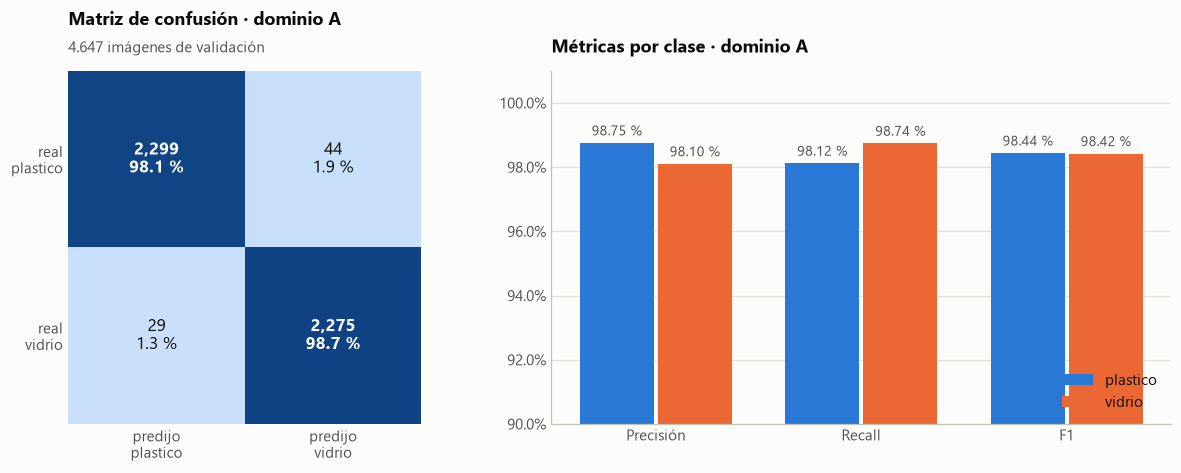

Macro-F1 en el dominio A: 98.43 %  —  sin sesgo entre clases.


In [10]:
cm_val = np.array(manifest["confusion_matrix"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.4),
                               gridspec_kw={"width_ratios": [1, 1.25]})
matriz_confusion(ax1, cm_val, clases, "Matriz de confusión · dominio A",
                 "4.647 imágenes de validación")

metricas = manifest["metricas_por_clase"]
nombres_m, llaves = ["Precisión", "Recall", "F1"], ["precision", "recall", "f1"]
x, ancho = np.arange(len(nombres_m)), 0.36
for i, (clase, color) in enumerate(zip(clases, [AZUL, NARANJA])):
    valores = [metricas[clase][k] * 100 for k in llaves]
    barras = ax2.bar(x + (i - 0.5) * (ancho + 0.02), valores, ancho,
                     label=clase, color=color)
    ax2.bar_label(barras, fmt="%.2f %%", padding=3, fontsize=9, color=TINTA_2)
ax2.set_xticks(x, nombres_m)
ax2.set_ylim(90, 101)
ax2.yaxis.set_major_formatter(PercentFormatter())
poner_titulo(ax2, "Métricas por clase · dominio A")
ax2.legend(loc="lower right")
limpiar(ax2)
plt.tight_layout()
plt.show()

macro_f1 = np.mean([metricas[c]["f1"] for c in clases]) * 100
print(f"Macro-F1 en el dominio A: {macro_f1:.2f} %  —  sin sesgo entre clases.")

En su propio dominio el modelo es prácticamente perfecto: F1 de 98,4 % en ambas
clases y macro-F1 de 98,43 %. **Ese es el número que suele citarse, y es el que
más engaña.**

### Los tres dominios comparados

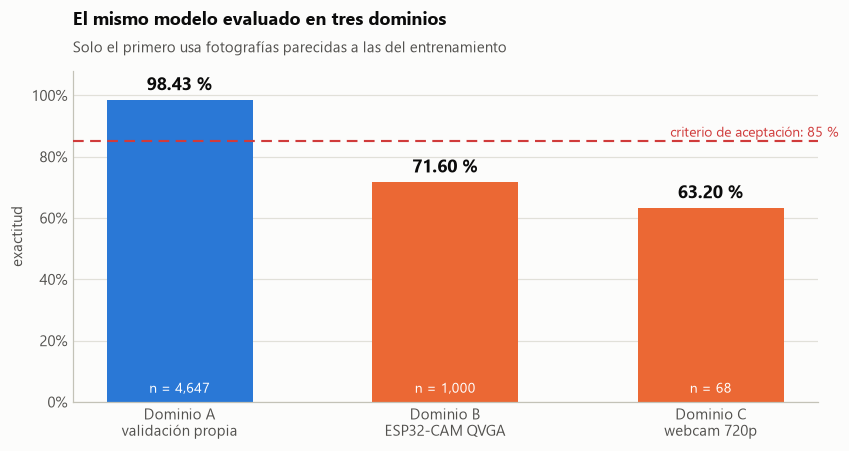

Caída del dominio A al B: 26.83 puntos porcentuales
Caída del dominio A al C: 35.23 puntos porcentuales


In [11]:
escenarios = [
    ("Dominio A\nvalidación propia",  98.43, 4647),
    ("Dominio B\nESP32-CAM QVGA",     71.60, 1000),
    ("Dominio C\nwebcam 720p",        63.20,   68),
]

fig, ax = plt.subplots(figsize=(7.8, 4.2))
# Azul: su propio dominio. Naranja: dominios nuevos. El color codifica esa distinción.
barras = ax.bar([e[0] for e in escenarios], [e[1] for e in escenarios], 0.55,
                color=[AZUL, NARANJA, NARANJA])
ax.bar_label(barras, fmt="%.2f %%", padding=4, fontsize=12,
             fontweight="bold", color=TINTA)
for i, (_, _, n) in enumerate(escenarios):
    ax.text(i, 3, f"n = {n:,}", ha="center", color="#ffffff", fontsize=9)

ax.axhline(85, color=CRITICO, linewidth=1.4, linestyle=(0, (5, 3)), zorder=3)
ax.text(2.48, 86.5, "criterio de aceptación: 85 %", ha="right",
        color=CRITICO, fontsize=9)
ax.set_ylim(0, 108)
ax.set_ylabel("exactitud")
ax.yaxis.set_major_formatter(PercentFormatter())
poner_titulo(ax, "El mismo modelo evaluado en tres dominios",
             "Solo el primero usa fotografías parecidas a las del entrenamiento")
limpiar(ax)
plt.tight_layout()
plt.show()

print(f"Caída del dominio A al B: {98.43-71.60:.2f} puntos porcentuales")
print(f"Caída del dominio A al C: {98.43-63.20:.2f} puntos porcentuales")

La analogía sirve para explicarlo en una exposición oral:

> **98,43 % es la nota de un examen con las mismas preguntas que se
> practicaron.** Los otros dos son exámenes sorpresa con preguntas nuevas.

El fenómeno se denomina **cambio de dominio** (*domain shift*). El modelo
incorporó regularidades del entorno de entrenamiento —fondo, iluminación,
encuadre, compresión— que no acompañan al material cuando cambia la cámara.

**Ninguna evaluación fuera del dominio A alcanza el criterio de aceptación del
85 %.**

### Matriz de confusión del dominio C

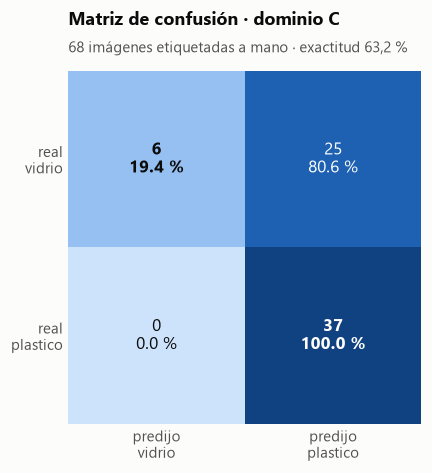

clase          precisión    recall        F1
────────────────────────────────────────────
vidrio            100.0%     19.4%     32.4%
plastico           59.7%    100.0%     74.7%
────────────────────────────────────────────
macro-F1                               53.6%

El recall de vidrio (19,4 %) es el hallazgo central: de cada 10 botellas
de vidrio, el modelo reconoce 2. Las otras 8 abrirían la compuerta errónea.


In [12]:
cm_web = np.array([[6, 25],      # real vidrio   → 6 vidrio, 25 plástico
                   [0, 37]])     # real plástico → 0 vidrio, 37 plástico
clases_web = ["vidrio", "plastico"]

fig, ax = plt.subplots(figsize=(5.8, 4.4))
matriz_confusion(ax, cm_web, clases_web, "Matriz de confusión · dominio C",
                 "68 imágenes etiquetadas a mano · exactitud 63,2 %")
plt.tight_layout()
plt.show()

vp_v, vp_p = cm_web[0, 0], cm_web[1, 1]
rec_v, rec_p = vp_v / cm_web[0].sum(), vp_p / cm_web[1].sum()
prec_v = vp_v / cm_web[:, 0].sum()
prec_p = vp_p / cm_web[:, 1].sum()
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v)
f1_p = 2 * prec_p * rec_p / (prec_p + rec_p)

print(f"{'clase':<12}{'precisión':>12}{'recall':>10}{'F1':>10}")
print("─" * 44)
print(f"{'vidrio':<12}{prec_v*100:>11.1f}%{rec_v*100:>9.1f}%{f1_v*100:>9.1f}%")
print(f"{'plastico':<12}{prec_p*100:>11.1f}%{rec_p*100:>9.1f}%{f1_p*100:>9.1f}%")
print("─" * 44)
print(f"{'macro-F1':<12}{'':>12}{'':>10}{(f1_v+f1_p)/2*100:>9.1f}%")
print()
print("El recall de vidrio (19,4 %) es el hallazgo central: de cada 10 botellas")
print("de vidrio, el modelo reconoce 2. Las otras 8 abrirían la compuerta errónea.")

La exactitud global del 63,2 % **oculta el problema**. Al desglosar por clase
aparece: precisión perfecta en vidrio (cuando dice vidrio, acierta) pero recall
del 19,4 % (casi nunca lo dice). El macro-F1 de 48,7 % refleja la realidad
mucho mejor que la exactitud.

### La confianza no permite filtrar los errores

Lo natural sería descartar las predicciones dudosas con un umbral. **Aquí no
funciona.**

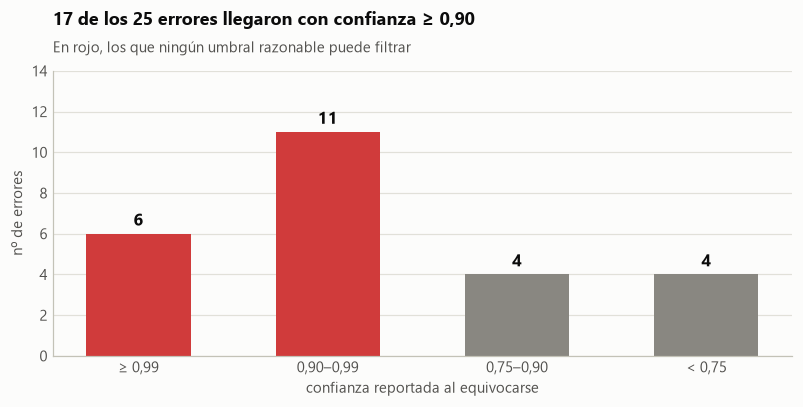

Dos errores llegaron con confianza exactamente 1,0000 sobre vidrio.

Asimetría en la confianza máxima observada:
   al predecir 'plastico' →  1,000000
   al predecir 'vidrio'   →  0,956
El modelo nunca está del todo seguro de que algo sea vidrio.


In [13]:
bandas_err = ["≥ 0,99", "0,90–0,99", "0,75–0,90", "< 0,75"]
errores    = [6, 11, 4, 4]

fig, ax = plt.subplots(figsize=(7.4, 3.8))
# Rojo: errores que ningún umbral razonable puede descartar.
barras = ax.bar(bandas_err, errores, 0.55, color=[CRITICO, CRITICO, APAGADO, APAGADO])
ax.bar_label(barras, padding=3, fontsize=11, fontweight="bold", color=TINTA)
ax.set_ylabel("nº de errores")
ax.set_xlabel("confianza reportada al equivocarse")
ax.set_ylim(0, 14)
poner_titulo(ax, "17 de los 25 errores llegaron con confianza ≥ 0,90",
             "En rojo, los que ningún umbral razonable puede filtrar")
limpiar(ax)
plt.tight_layout()
plt.show()

print("Dos errores llegaron con confianza exactamente 1,0000 sobre vidrio.")
print()
print("Asimetría en la confianza máxima observada:")
print("   al predecir 'plastico' →  1,000000")
print("   al predecir 'vidrio'   →  0,956")
print("El modelo nunca está del todo seguro de que algo sea vidrio.")

### Repetir la captura tampoco rescata

La ESP32-CAM toma **3 fotografías** por residuo, así que cabría esperar que la
repetición corrija los casos dudosos. Sobre 32 ráfagas de 3 capturas del mismo
objeto, **30 resultaron unánimes (93,8 %)**.

Suena bien, pero corta para los dos lados: **cuando el modelo se equivoca, se
equivoca en las tres**. La estabilidad solo ayuda si la predicción base es
correcta.

## 5.2. Influencia de los factores de captura

Esta sección responde a la pregunta que la 2.4 dejó abierta: ¿qué factor del
entorno explica el rendimiento?

### Evidencia 1 — la clase que falla cambia con la cámara

Si el modelo hubiera aprendido a distinguir materiales, fallaría en la misma
clase en todos los dominios. No ocurre.

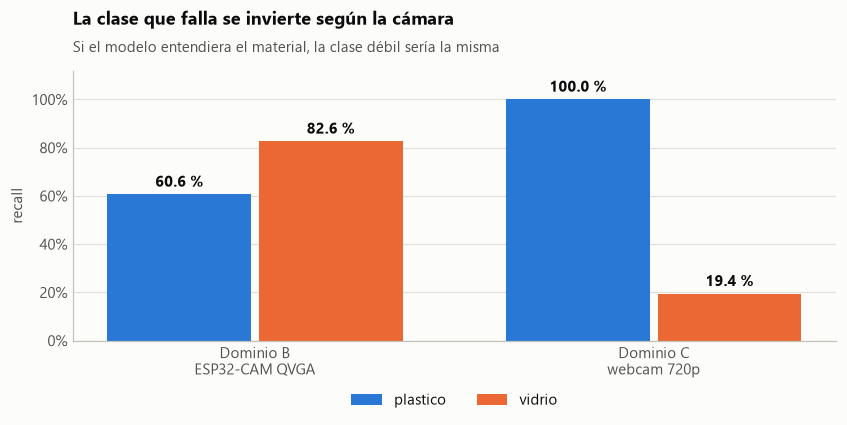

In [14]:
recall_dom = {
    "Dominio B\nESP32-CAM QVGA": {"plastico": 60.60, "vidrio": 82.60},
    "Dominio C\nwebcam 720p":    {"plastico": 100.0, "vidrio": 19.40},
}

fig, ax = plt.subplots(figsize=(7.8, 4.2))
x, ancho = np.arange(len(recall_dom)), 0.36
for i, (clase, color) in enumerate(zip(["plastico", "vidrio"], [AZUL, NARANJA])):
    valores = [v[clase] for v in recall_dom.values()]
    barras = ax.bar(x + (i - 0.5) * (ancho + 0.02), valores, ancho,
                    label=clase, color=color)
    ax.bar_label(barras, fmt="%.1f %%", padding=3, fontsize=10,
                 fontweight="bold", color=TINTA)
ax.set_xticks(x, list(recall_dom))
ax.set_ylim(0, 112)
ax.set_ylabel("recall")
ax.yaxis.set_major_formatter(PercentFormatter())
poner_titulo(ax, "La clase que falla se invierte según la cámara",
             "Si el modelo entendiera el material, la clase débil sería la misma")
ax.legend(loc="lower center", ncols=2, bbox_to_anchor=(0.5, -0.30))
limpiar(ax)
plt.tight_layout()
plt.show()

| Dominio | Recall plástico | Recall vidrio |
|---|---:|---:|
| B · ESP32-CAM QVGA (1.000 fotos) | 60,60 % | **82,60 %** |
| C · Webcam 720p (68 fotos) | **100 %** | 19,40 % |

En un dominio la clase débil es el plástico; en el otro, el vidrio — y por un
margen enorme. **Esto no es ruido estadístico:** es la firma de un modelo que
aprendió el contexto de captura, no la propiedad física del envase.

### Evidencia 2 — la iluminación desplaza el resultado

La sección 2.4 midió una correlación de **r = +0,214** entre el brillo de la
imagen y `P(vidrio)`: un 43 % de la fuerza que tiene el material real. El dato
independiente lo confirma: sobre el dominio B, 300 capturas con mejor
iluminación subieron del **71,60 % al 77,33 %** sin cambiar el modelo.

### Evidencia 3 — la restricción binaria (R1) en la práctica

Se evaluaron 23 objetos que no son ni vidrio ni plástico:

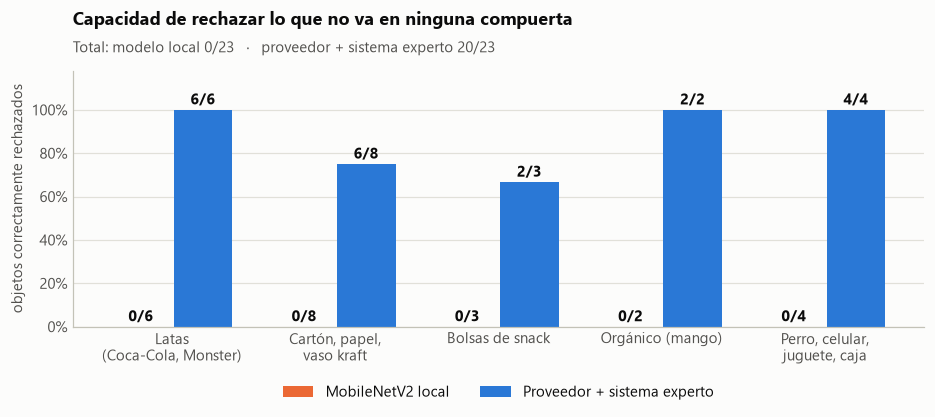

In [15]:
grupos = [
    ("Latas\n(Coca-Cola, Monster)",   6, 0, 6),
    ("Cartón, papel,\nvaso kraft",    8, 0, 6),
    ("Bolsas de snack",               3, 0, 2),
    ("Orgánico (mango)",              2, 0, 2),
    ("Perro, celular,\njuguete, caja",4, 0, 4),
]

fig, ax = plt.subplots(figsize=(8.6, 4.2))
x, ancho = np.arange(len(grupos)), 0.36
b1 = ax.bar(x - (ancho + 0.02)/2, [l/n*100 for _, n, l, _ in grupos], ancho,
            label="MobileNetV2 local", color=NARANJA)
b2 = ax.bar(x + (ancho + 0.02)/2, [p/n*100 for _, n, _, p in grupos], ancho,
            label="Proveedor + sistema experto", color=AZUL)
for barras, datos in ((b1, [(l, n) for _, n, l, _ in grupos]),
                      (b2, [(p, n) for _, n, _, p in grupos])):
    for barra, (v, n) in zip(barras, datos):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 2.5,
                f"{v}/{n}", ha="center", fontsize=9.5,
                fontweight="bold", color=TINTA)
ax.set_xticks(x, [g[0] for g in grupos])
ax.set_ylim(0, 118)
ax.set_ylabel("objetos correctamente rechazados")
ax.yaxis.set_major_formatter(PercentFormatter())
poner_titulo(ax, "Capacidad de rechazar lo que no va en ninguna compuerta",
             "Total: modelo local 0/23   ·   proveedor + sistema experto 20/23")
ax.legend(loc="lower center", ncols=2, bbox_to_anchor=(0.5, -0.34))
limpiar(ax)
plt.tight_layout()
plt.show()

**0 de 23**, y no con dudas sino con confianza altísima:

| Objeto | Predicción del modelo local | Confianza |
|---|---|---:|
| Mango | `plastico` | **1,0000** |
| Lata de Coca-Cola | `plastico` | 0,9998 |
| Servilleta de papel | `plastico` | 1,0000 |
| Un perro | `plastico` | 1,0000 |

Esto **no es un fallo corregible con más entrenamiento**: es la restricción R1.
Un clasificador de dos clases no puede expresar "ninguna de las dos". Solo el
sistema experto, con sus 193 reglas y sus cinco conclusiones posibles, puede
concluir `LATA`, `ORGANICO` o `DESCONOCIDO` y dejar ambas compuertas cerradas.

---
# 6. Resultados de la optimización de la política de decisión

> **Nota de adaptación.** El informe de referencia dedica esta sección a
> optimizar un presupuesto entre canales. Aquí no hay presupuesto que repartir,
> pero sí un problema de optimización estructuralmente equivalente: **cómo
> combinar dos señales predictivas para maximizar el acierto minimizando el
> riesgo de abrir la compuerta equivocada.** La "asignación" que se optimiza es
> el peso de cada señal en la decisión final.

## 6.1. Las dos señales disponibles

Por cada residuo, la ESP32-CAM toma 3 fotografías. Cada una genera 2 votos
independientes, de modo que la decisión dispone de **6 diagnósticos**.
Comparados sobre las mismas 68 imágenes:

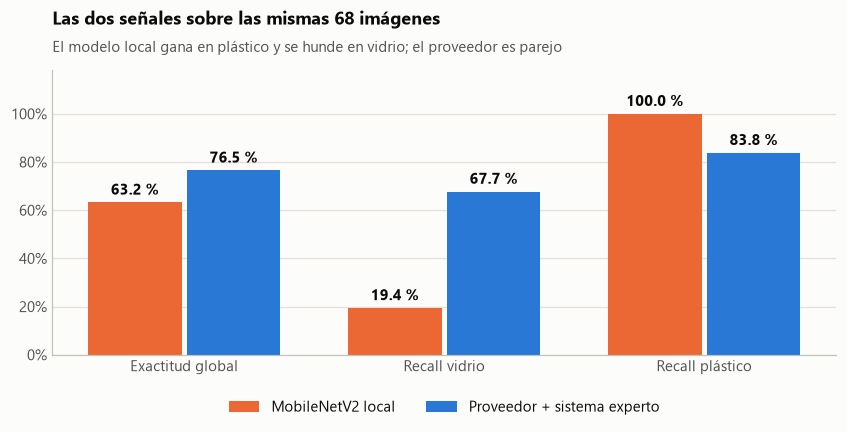

In [16]:
señales = {
    "MobileNetV2 local":            {"global": 63.2, "vidrio": 19.4, "plastico": 100.0},
    "Proveedor + sistema experto":  {"global": 76.5, "vidrio": 67.7, "plastico":  83.8},
}

fig, ax = plt.subplots(figsize=(7.8, 4.2))
categorias = ["Exactitud global", "Recall vidrio", "Recall plástico"]
llaves_c   = ["global", "vidrio", "plastico"]
x, ancho   = np.arange(len(categorias)), 0.36
for i, (nombre, color) in enumerate(zip(señales, [NARANJA, AZUL])):
    valores = [señales[nombre][k] for k in llaves_c]
    barras = ax.bar(x + (i - 0.5)*(ancho + 0.02), valores, ancho,
                    label=nombre, color=color)
    ax.bar_label(barras, fmt="%.1f %%", padding=3, fontsize=10,
                 fontweight="bold", color=TINTA)
ax.set_xticks(x, categorias)
ax.set_ylim(0, 118)
ax.yaxis.set_major_formatter(PercentFormatter())
poner_titulo(ax, "Las dos señales sobre las mismas 68 imágenes",
             "El modelo local gana en plástico y se hunde en vidrio; el proveedor es parejo")
ax.legend(loc="lower center", ncols=2, bbox_to_anchor=(0.5, -0.26))
limpiar(ax)
plt.tight_layout()
plt.show()

El perfil de las señales es **complementario, no redundante**: el modelo local
es perfecto en plástico y pésimo en vidrio; el proveedor es parejo. Esa
asimetría es justamente lo que hay que explotar.

## 6.2. Políticas evaluadas

La política implementada en `vision/voting.py`, replicada en el firmware:

```
1. ¿Hay mayoría estricta en los 3 votos del proveedor?   → se usa esa
2. Si no, ¿hay mayoría estricta en los 3 votos locales?  → se usa esa
3. Si ninguna alcanza mayoría                            → "desconocido", no abre
```

`desconocido` es una **abstención**: se registra como diagnóstico pero no suma
a ninguna clase.

Caso de prueba: una botella de vidrio real donde el proveedor acierta las 3
veces y el modelo local falla las 3 —exactamente lo que predicen las tasas
medidas—.

| Política | Resultado | Lectura |
|---|---|---|
| **Proveedor primario** (vigente) | **VIDRIO** ✅ | Correcta |
| Voto igualitario 3–3 | empate → `desconocido` | No abre; segura pero inútil |
| Modelo local primario | **PLÁSTICO** ❌ | Compuerta equivocada |

La política vigente es la única de las tres que resuelve el caso. **La
optimización ya está hecha y la evidencia la respalda.**

## 6.3. Riesgo residual y mejora propuesta

Queda un flanco abierto. Si el proveedor se cae o se abstiene, el respaldo
local decide **solo** — con un recall de vidrio de entre 19 % y 83 % según el
dominio. Puede abrir la compuerta de plástico ante una botella de vidrio, que
es justo lo que la política conservadora del sistema experto (rechazar si
CF < 0,75) intenta evitar.

**Propuesta, aún no implementada:** aprovechar la asimetría medida y permitir
el respaldo local **solo cuando su mayoría sea `plastico`** —donde mide 100 %
de recall— y **nunca cuando sea `vidrio`** —donde mide 19,4 %—.

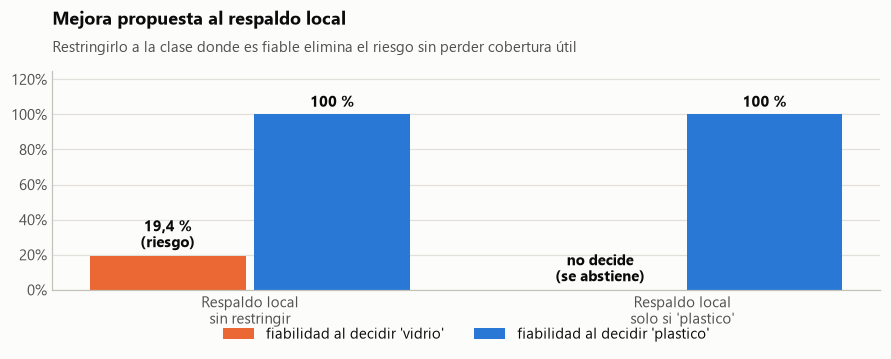

In [17]:
fig, ax = plt.subplots(figsize=(8.2, 3.6))
politicas = [
    ("Respaldo local\nsin restringir",  19.4, 100.0),
    ("Respaldo local\nsolo si 'plastico'", np.nan, 100.0),
]
x, ancho = np.arange(len(politicas)), 0.36
v_vidrio  = [p[1] for p in politicas]
v_plastic = [p[2] for p in politicas]

b1 = ax.bar(x - (ancho+0.02)/2, [0 if np.isnan(v) else v for v in v_vidrio], ancho,
            label="fiabilidad al decidir 'vidrio'", color=NARANJA)
b2 = ax.bar(x + (ancho+0.02)/2, v_plastic, ancho,
            label="fiabilidad al decidir 'plastico'", color=AZUL)
ax.bar_label(b1, labels=["19,4 %\n(riesgo)", "no decide\n(se abstiene)"],
             padding=3, fontsize=9.5, fontweight="bold", color=TINTA)
ax.bar_label(b2, fmt="%.0f %%", padding=3, fontsize=9.5,
             fontweight="bold", color=TINTA)
ax.set_xticks(x, [p[0] for p in politicas])
ax.set_ylim(0, 125)
ax.yaxis.set_major_formatter(PercentFormatter())
poner_titulo(ax, "Mejora propuesta al respaldo local",
             "Restringirlo a la clase donde es fiable elimina el riesgo sin perder cobertura útil")
ax.legend(loc="lower center", ncols=2, bbox_to_anchor=(0.5, -0.30))
limpiar(ax)
plt.tight_layout()
plt.show()

---
# 7. Conclusiones y recomendaciones

## 7.1. Conclusiones

**C1 · El modelo es correcto como software; su problema es de generalización.**
Carga, ejecuta y entrega probabilidades coherentes. Su mecanismo de repliegue
está bien construido: si no hay runtime TFLite disponible, el servicio sigue
operando solo con el proveedor. Ningún defecto de implementación explica los
resultados.

**C2 · No generaliza fuera de su dataset de entrenamiento** *(objetivo O2)*.
La exactitud cae de 98,43 % a 71,60 % y 63,2 % al cambiar de cámara. El 98,43 %
declarado es, además, exactitud de **validación** y no de prueba, por lo que
está optimistamente sesgado incluso dentro de su dominio.

**C3 · Aprendió el contexto además del material** *(objetivos O1 y O2)*. Tres
evidencias convergen: la clase que falla se invierte según la cámara; el brillo
de la imagen correlaciona con la salida a un 43 % de la fuerza del material
real; y la iluminación por sí sola mueve la exactitud casi 6 puntos.

**C4 · Su confianza no es informativa** *(objetivo O3)*. 17 de los 25 errores
llegaron con confianza ≥ 0,90 y dos con exactamente 1,0000. Ningún umbral
permite separar aciertos de errores. Repetir la captura tampoco rescata: el
93,8 % de las ráfagas es unánime, también al fallar.

**C5 · No puede rechazar nada** *(objetivo O4)*. 0 de 23 objetos no permitidos,
frente a 20 de 23 del sistema experto. Es una limitación estructural de la
arquitectura binaria, no corregible con más datos.

**C6 · Su papel de respaldo está justificado con evidencia** *(objetivo O5)*.
De las tres políticas evaluadas, la vigente es la única que resuelve
correctamente el caso de prueba.

**C7 · No es reproducible** *(objetivo O6)*. La comparación de huellas
numéricas descarta que los puntos de control disponibles sean su origen.

## 7.2. Recomendaciones

**Prioridad alta**

**R1 · Restringir el respaldo local a la clase `plastico`.** Es un cambio de
pocas líneas en `vision/voting.py`, elimina el riesgo identificado en 6.3 y no
sacrifica cobertura útil: el modelo conserva el 100 % de recall en la clase que
sí domina.

**R2 · Reentrenar con fotografías de la ESP32-CAM.** Es el experimento **E1**
de `PROPUESTA-NUEVO-MODELO.md`. La evidencia de C3 apunta a que el problema
está en los datos, no en la arquitectura: conviene agotar esa vía antes de
cambiar de modelo.

**R3 · Solicitar la corrida `run_20260721_2129` completa** — script, particiones,
semillas y el `.keras` previo a la exportación. Sin línea base reproducible no
se puede demostrar que un candidato mejora.

**Prioridad media**

**R4 · Reservar un conjunto de prueba independiente**, particionado por objeto
o sesión completa —nunca fotogramas sueltos de una misma ráfaga—, y consultarlo
una sola vez al final.

**R5 · Incorporar abstención al modelo local**: calibrar las probabilidades y
permitir que responda `desconocido` cuando el margen entre clases sea
insuficiente. Se reportarían conjuntamente cobertura y exactitud cubierta.

**R6 · Adoptar macro-F1 como métrica de selección**, no exactitud global. En el
dominio C la exactitud dice 63,2 % y el macro-F1 dice 48,7 %; el segundo
describe mucho mejor la realidad.

**Prioridad baja**

**R7 · Ampliar la validación del dominio B** con capturas balanceadas por
objeto, sesión y nivel de iluminación, para separar el efecto de la luz del de
la capacidad de generalización.

### Criterio de reemplazo

Según `PROPUESTA-NUEVO-MODELO.md`, un candidato solo sustituye al modelo actual
si alcanza **macro-F1 ≥ 85 %** *y* **recall ≥ 85 % en cada clase** sobre un
conjunto de prueba de la ESP32-CAM que ningún candidato haya visto durante el
entrenamiento.

---

## Anexo · Verificación con fotografías propias

Celda opcional: ejecuta el modelo sobre imágenes reales si están disponibles.
La carpeta `images/` está excluida por `.gitignore`, de modo que no acompaña al
repositorio; si no existe, la celda lo informa sin fallar.

200 fotografías · modelo=model.tflite runtime=ai-edge-litert



  plastico    190 / 200  (95.0 %)
  vidrio       10 / 200  (5.0 %)


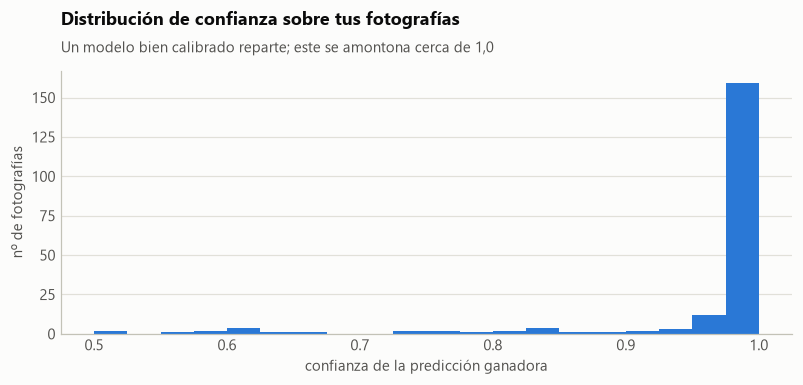

In [18]:
import sys

SERVICIO = MODELO_DIR.parent
if str(SERVICIO) not in sys.path:
    sys.path.insert(0, str(SERVICIO))

CARPETA_FOTOS = SERVICIO.parent.parent / "images" / "capturas"

if not CARPETA_FOTOS.exists():
    print(f"No se encontró {CARPETA_FOTOS}")
    print("Apunta CARPETA_FOTOS a un directorio con archivos .jpg para ejecutarla.")
else:
    import cv2
    from vision.local_model import LocalMaterialClassifier

    clf = LocalMaterialClassifier()
    fotos = sorted(CARPETA_FOTOS.glob("*.jpg"))
    print(f"{len(fotos)} fotografías · modelo={clf.model_path.name} runtime={clf.runtime}\n")

    conteo, confianzas = {"plastico": 0, "vidrio": 0}, []
    for ruta in fotos:
        img = cv2.imread(str(ruta))
        if img is None:
            continue
        p = clf.predict(img)
        conteo[p["material"]] += 1
        confianzas.append(p["confidence"])

    total = sum(conteo.values())
    for material, n in conteo.items():
        print(f"  {material:<10} {n:>4} / {total}  ({n/total*100:.1f} %)")

    fig, ax = plt.subplots(figsize=(7.4, 3.6))
    ax.hist(confianzas, bins=20, range=(0.5, 1.0), color=AZUL)
    ax.set_xlabel("confianza de la predicción ganadora")
    ax.set_ylabel("nº de fotografías")
    poner_titulo(ax, "Distribución de confianza sobre tus fotografías",
                 "Un modelo bien calibrado reparte; este se amontona cerca de 1,0")
    limpiar(ax)
    plt.tight_layout()
    plt.show()

---

## Referencias

- [`README.md`](README.md) — el modelo dentro del servicio de visión
- [`PROPUESTA-NUEVO-MODELO.md`](PROPUESTA-NUEVO-MODELO.md) — plan de reemplazo (E0–E3)
- [`../scripts/entrenamiento/README.md`](../scripts/entrenamiento/README.md) — entrenamiento de candidatos
- [`../../../docs/VALIDACION-MODELO-LOCAL-ESP32-CAM.md`](../../../docs/VALIDACION-MODELO-LOCAL-ESP32-CAM.md) — protocolo de validación
- Sandler et al. (2018), [*MobileNetV2: Inverted Residuals and Linear Bottlenecks*](https://openaccess.thecvf.com/content_cvpr_2018/papers/Sandler_MobileNetV2_Inverted_Residuals_CVPR_2018_paper.pdf), CVPR
- Shortliffe & Buchanan (1975), *A model of inexact reasoning in medicine* — origen de los factores de certeza del sistema experto

**Responsable del modelo:** Axel Hernández (IA + Sistema Experto).